# XGBoost Classification

## Imports

In [22]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, plot_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


## Load Dataset

In [23]:
# Load and clean dataset
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)
display(data.head(30))

threshold = 0.75
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

# Auto-convert object columns that look numeric (e.g., 'Alter_0')
object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(
    f"Converted {len(numeric_like_cols)} mostly-numeric columns: {numeric_like_cols}"
)
print(f"Cleaned dataset shape: {data.shape}")


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_56243/3515101441.py:3: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,"56,9691991786448",0,112,",982456140350877","32,8731097961867",0,130.0,80.0,50.0,...,"9,44","4,38","3,99","14,1","25,8","7,8","3,99","3,99","3,99","3,99"
1,2,"69,4976043805613",0,104,"1,04","30,1102788964583",0,160.0,70.0,90.0,...,"19,8","8,97","7,75","21,9","41,3","20,1","7,35",NaN,"7,45","8,11"
2,2,"72,0492813141684",0,129,",941605839416058","44,7348800491207",0,140.0,90.0,50.0,...,"13,9","4,75","3,99","20,3","52,4","18,6","3,99","3,99","3,99","3,99"
3,2,"70,8145106091718",0,99,",876106194690266","26,2595847484332",0,130.0,90.0,40.0,...,20,"8,73","7,85","25,3","50,7",17,0,NaN,"7,63","9,02"
4,2,"62,1601642710472",1,125,NaN,"42,4366343891054",1,180.0,100.0,80.0,...,"16,9","9,14","8,3","29,5",43,"17,9","8,13",0,"8,4","8,51"
5,2,"73,82340862423",1,97,",989795918367347","26,4462809917355",0,157.0,85.0,72.0,...,"13,1",8,"7,4","15,1","26,4","15,2","7,4","3,89","7,53","8,15"
6,2,"58,4284736481862",1,92,",978723404255319","25,78125",1,130.0,85.0,45.0,...,"16,5","8,61",0,"21,5",48,"20,4",0,NaN,"7,71","9,31"
7,2,"54,5954825462012",0,NaN,NaN,"32,4661454995942",1,140.0,80.0,60.0,...,"18,7","8,84","8,54","28,2","42,7","15,9","8,28",0,"8,44","8,83"
8,2,"76,1724845995893",0,92,",884615384615385","27,2392244832559",0,150.0,110.0,40.0,...,"18,8","8,84","7,71","18,6","40,4","20,8","7,03",0,"7,77","8,3"
9,2,"46,7953456536619",1,81,",931034482758621","20,8209399167162",1,110.0,70.0,40.0,...,"9,25","4,13","3,99","15,7","39,9","14,5","3,99","3,99","3,99","3,99"


Converted 6 mostly-numeric columns: ['Alter_0', 'BMI_0', 'hba1c0', 'TyG_Index_neu', 'crp0', 'Kreat0']
Cleaned dataset shape: (1678, 101)


## Dropping dependant Features

In [24]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)
print(list(data.columns))

['OUTCOME_3Kat_KHK', 'Alter_0', 'geschlecht', 'waist_0', 'WHR_0', 'BMI_0', 'currsmo0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'insulm0', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'diabetes_ADA_final_0', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'CALCIUM', 'PHOSPHAT', 'Kalium0', 'GPC4_alle', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'ProBNP_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', 'GESAMT_B', 'GESAMT_T', 'GESAMT_A', 'APPLEAN', 'ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_We

## Preprocessing

In [ ]:
# Split data into features and target
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
    ]
resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)
if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )


numerical_features = [col for col in X.columns if col not in categorical_features]

if categorical_features:
    X[categorical_features] = X[categorical_features].astype(str)

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): sample -> {numerical_features[:5]}")

# Note: Features with >75% missing were already removed in Cell 4
# (data = data.loc[:, data.isnull().mean() < 0.75])

# Remove highly correlated numerical features
if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerische Features: {len(numerical_features)}")
print(f"After cleaning - Kategoriale Features: {len(categorical_features)}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_pre = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features),
    ]
)


Forced 53 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (86): sample -> ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0']
Features with >75.0% missing: 0
Removing 1 highly correlated features
After cleaning - Numerische Features: 85
After cleaning - Kategoriale Features: 7


## Build Pipeline

In [26]:
# Feature selection BEFORE pipeline (more stable for CV)
# Fit preprocessor and select features on full training set
temp_preprocessor = preprocessor.fit(X_train, y_train)
X_train_transformed = temp_preprocessor.transform(X_train)
X_test_transformed = temp_preprocessor.transform(X_test)

# Select features based on full training set (top 50 for binary problem)
selector = SelectKBest(mutual_info_classif, k=50)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

# Pipeline with SMOTE and regularized XGBoost (features already selected)
pipeline = Pipeline(
    [
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=200,        # Reduced from potential higher values
            learning_rate=0.01,      # Slower learning to prevent overfitting
            max_depth=3,             # Shallower trees (reduced from 6)
            min_child_weight=5,      # Stronger regularization
            subsample=0.8,           # Row subsampling
            colsample_bytree=0.7,    # Column subsampling
            reg_lambda=3.0,          # L2 regularization
            reg_alpha=1.5,           # L1 regularization
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )),
    ]
)

# CV and training on selected features
# Perform 5-fold cross-validation with balanced accuracy
cv_scores = cross_val_score(pipeline, X_train_selected, y_train, cv=5, scoring='balanced_accuracy')

# Fit the model on the training data
pipeline.fit(X_train_selected, y_train)

# Predict on the test set (using selected features)
y_pred = pipeline.predict(X_test_selected)
y_proba = pipeline.predict_proba(X_test_selected)




Selected 50 features out of 103


## Evaluation

In [27]:

# Classification Report
report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"])

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f}")
print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
print("\nClassification Report:")
print(report)


Mean Cross-Validation Balanced Accuracy: 0.7076
Test Balanced Accuracy: 0.6995

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.37      0.61      0.46        57
Significant Stenosis       0.91      0.78      0.84       279

            accuracy                           0.76       336
           macro avg       0.64      0.70      0.65       336
        weighted avg       0.82      0.76      0.78       336



In [14]:
# Overfitting Check
from sklearn.metrics import balanced_accuracy_score, accuracy_score

# Predictions on training and test sets
y_pred_train = pipeline.predict(X_train_selected)
y_pred_test = y_pred  # Already computed

# Calculate balanced accuracy for both
train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

# Calculate regular accuracy for both
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Overfitting Check")
print(f"Training Balanced Accuracy: {train_bal_acc:.4f}")
print(f"Test Balanced Accuracy:     {test_bal_acc:.4f}")
print(f"Difference:                 {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Training Accuracy:          {train_acc:.4f}")
print(f"Test Accuracy:              {test_acc:.4f}")
print(f"Difference:                 {train_acc - test_acc:.4f}")
print()

# Warning if gap is too large
gap = train_bal_acc - test_bal_acc
if gap > 0.15:
    print("WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap > 0.10:
    print("CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("Model shows good generalization (small gap between train/test)")



Overfitting Check
Training Balanced Accuracy: 0.7488
Test Balanced Accuracy:     0.7240
Difference:                 0.0248

Training Accuracy:          0.7846
Test Accuracy:              0.7619
Difference:                 0.0227

Model shows good generalization (small gap between train/test)


## Visualization Binary

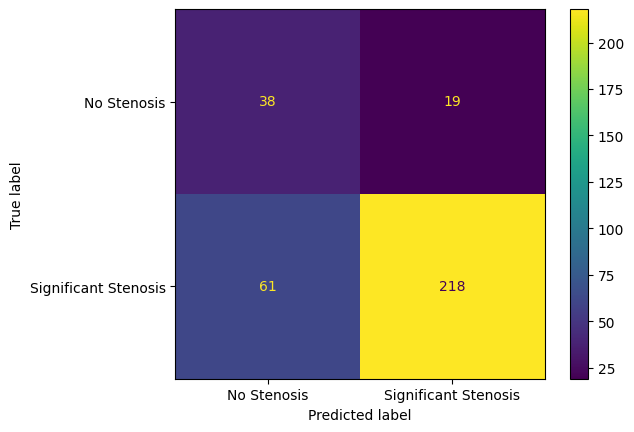

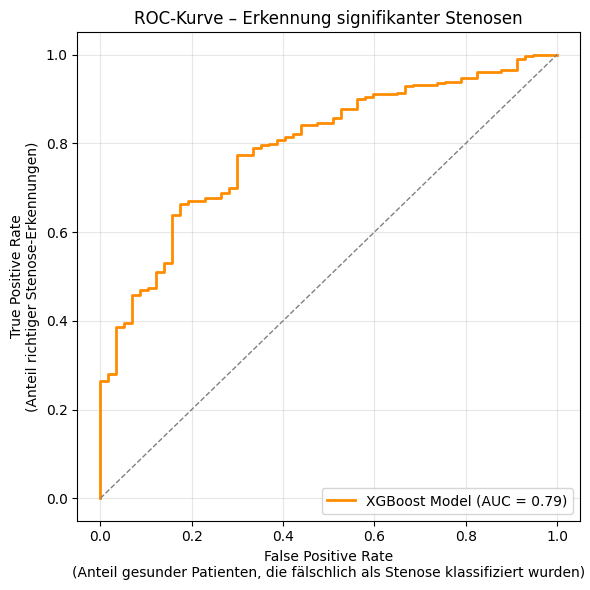

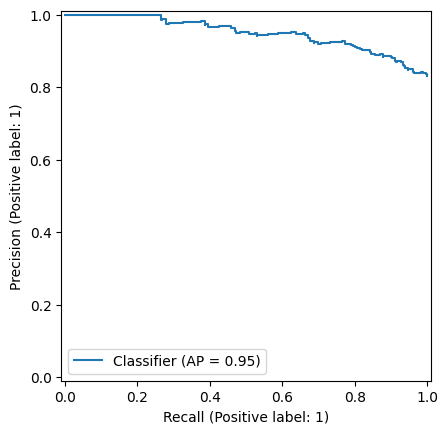

In [8]:

# Get preprocessed test data (already transformed and selected)
# X_test_selected was created in Cell 10
clf = pipeline.named_steps["classifier"]
y_pred = clf.predict(X_test_selected)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Stenosis", "Significant Stenosis"])

# ROC Curve
y_prob = clf.predict_proba(X_test_selected)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"XGBoost Model (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

# Achsenbeschriftungen und Titel
plt.xlabel("False Positive Rate\n(Anteil gesunder Patienten, die fälschlich als Stenose klassifiziert wurden)")
plt.ylabel("True Positive Rate\n(Anteil richtiger Stenose-Erkennungen)")
plt.title("ROC-Kurve – Erkennung signifikanter Stenosen")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, clf.predict_proba(X_test_selected)[:, 1])


# Feature Importance

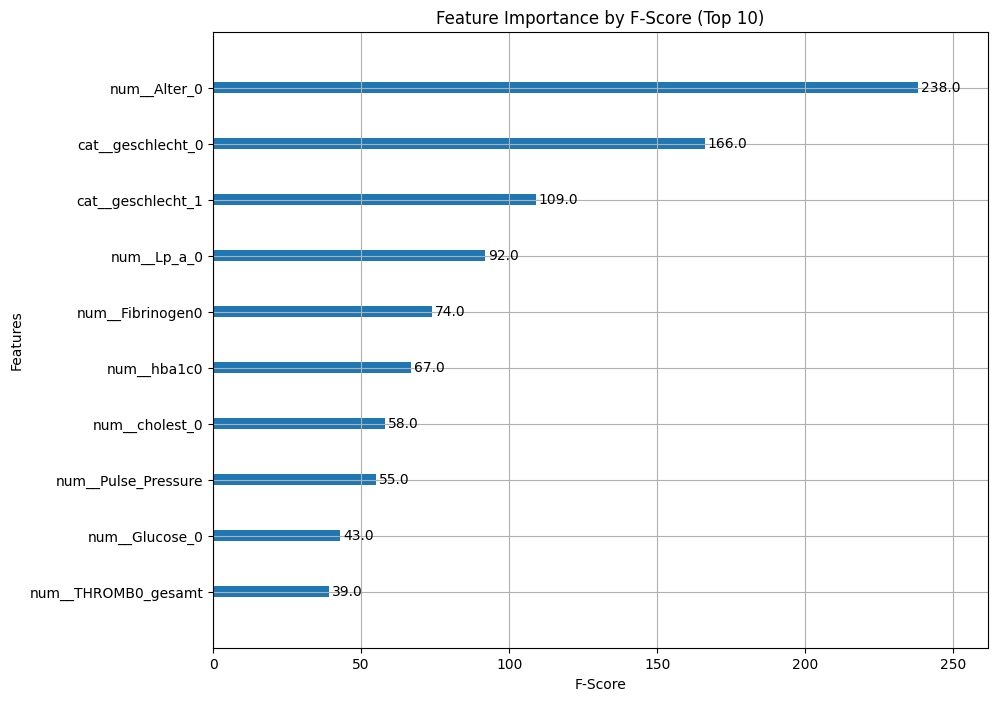

In [10]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get feature names from preprocessor and map to selected features
all_feature_names = temp_preprocessor.get_feature_names_out()
selected_indices = selector.get_support(indices=True)
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# 2. Extract the trained XGBoost model
xgb_model = pipeline.named_steps['classifier']

# 3. Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. Set the feature names on the Booster object (use selected feature names)
booster.feature_names = selected_feature_names

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

--- Worst 10 Features by F-Score Importance ---
                Feature  Importance
37            num__tsh0         1.0
10       num__RR_syst_0         2.0
31  num__GOT_GPT_Ratio0         2.0
30            num__got0         2.0
35          num__quick0         3.0
32            num__ggt0         3.0
34            num__cpk0         5.0
36            num__ptt0         5.0
28            num__crp0         6.0
29          num__Kreat0         7.0


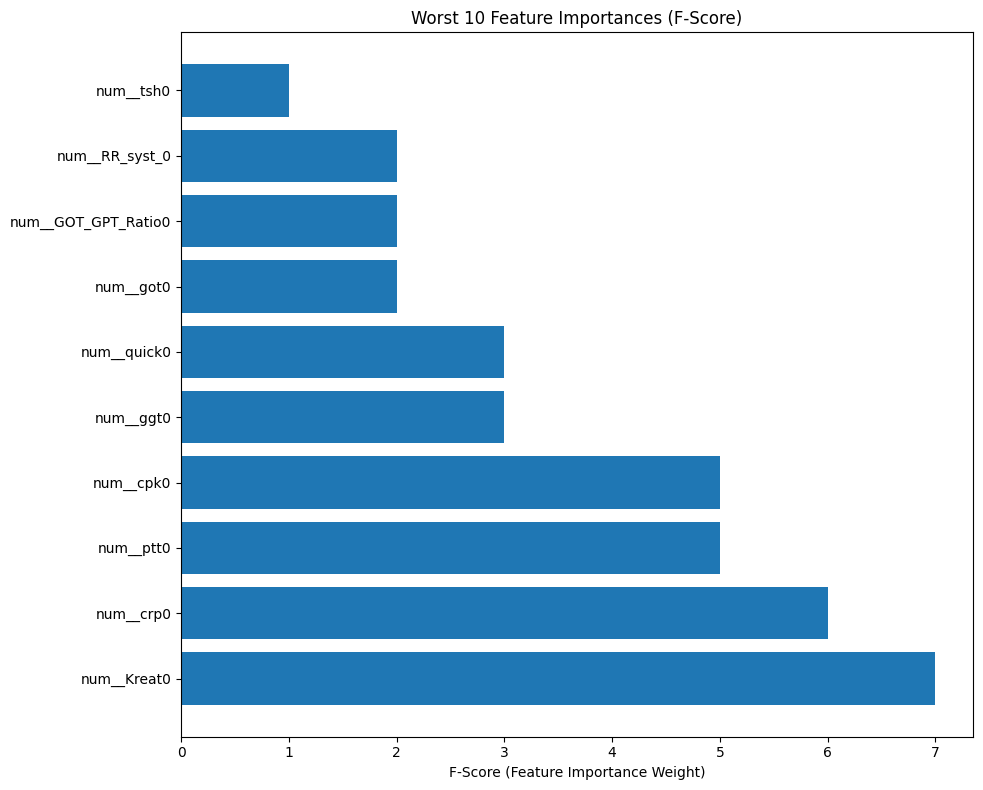

In [11]:
ig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

# You must also define ax_top even if you don't plot on it, 
# or else you will get an index error later when you try to access ax_worst.
# Let's use a dummy plot on ax_top for now to keep the array structure intact.
ax_top.set_visible(False) # Hide the first axis if you only want to see the second one

# --- Your code snippet starts here ---
importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

# Plot Worst 10 on the second subplot
ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:
# Inspect how each feature is treated
feature_treatment = pd.DataFrame({
    'feature': X.columns,
    'pandas_dtype': X.dtypes.astype(str),
    'treated_as': [
        'categorical' if col in categorical_features else (
            'numerical' if col in numerical_features else 'other'
        )
        for col in X.columns
    ]
})
display(feature_treatment.sort_values(['treated_as', 'feature']).reset_index(drop=True))
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")


,feature,pandas_dtype,treated_as
0,ANY_OPE,object,categorical
1,ANY_OPO,object,categorical
2,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,object,categorical
3,Osteoporose_T_Wert_abhängig,object,categorical
4,currsmo0,object,categorical
...,...,...,...
88,quick0,float64,numerical
89,remnantCholesterol0,float64,numerical
90,triglyc_0,float64,numerical
91,tsh0,float64,numerical


Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (86): ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'insulm0', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'CALCIUM', 'PHOSPHAT', 'Kalium0', 'GPC4_alle', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'ProBNP_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', '

## Gridsearch

In [13]:
# Hyperparameter search (using selected features)
param_grid = {
    'classifier__n_estimators': [150, 200, 300],
    'classifier__max_depth': [2, 3, 4],
    'classifier__learning_rate': [0.01, 0.02, 0.05],
    'classifier__subsample': [0.7, 0.8],
    'classifier__colsample_bytree': [0.6, 0.7],
    'classifier__min_child_weight': [3, 5, 7],
    'classifier__reg_lambda': [2.0, 3.0, 5.0],
    'classifier__reg_alpha': [1.0, 1.5, 2.0],
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
)
# Use X_train_selected (features already selected in Cell 10)
grid_search.fit(X_train_selected, y_train)

print(f"Best balanced accuracy (CV): {grid_search.best_score_:.4f}")
print('Best params:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

best_model = grid_search.best_estimator_
# Use X_test_selected (features already selected in Cell 10)
y_pred_gs = best_model.predict(X_test_selected)
balanced_acc_gs = balanced_accuracy_score(y_test, y_pred_gs)
print(f"Test balanced accuracy (best model): {balanced_acc_gs:.4f}")


Fitting 3 folds for each of 2916 candidates, totalling 8748 fits


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x1249a6600>>
Traceback (most recent call last):
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 685, in _next_wrapper
    return self._handle_exception(lambda: int(self.next(input_data)), 0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 598, in _handle_exception
    return fn()
           ^^^^
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 685, in <lambda>
    return self._handle_exception(lambda: int(self.next(input_data)), 0)
                                              ^^^^^^^^^^^

KeyboardInterrupt: 

In [23]:
# Extrahiere alle für das Modell genutzten Daten der kategorialen Features
if categorical_features:
    categorical_data_used = X[categorical_features].copy()
    print(f'Kategorische Features: {len(categorical_features)} -> {categorical_features}')
    print('Form des kategorialen Datensatzes:', categorical_data_used.shape)
    display(categorical_data_used)
else:
    print('Keine kategorialen Features für dieses Modell gefunden.')

Kategorische Features: 7 -> ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Form des kategorialen Datensatzes: (1678, 7)


,ANY_OPE,ANY_OPO,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,Osteoporose_T_Wert_abhängig,currsmo0,diabetes_ADA_final_0,geschlecht
0,0.0,0.0,0.0,0.0,0,1,0
1,0.0,0.0,0.0,0.0,0,0,0
2,1.0,0.0,0.0,0.0,0,1,0
3,0.0,0.0,0.0,0.0,0,1,0
4,1.0,0.0,1.0,0.0,1,1,1
...,...,...,...,...,...,...,...
1673,nan,nan,nan,nan,0,0,1
1674,nan,nan,nan,nan,0,0,0
1675,nan,nan,nan,nan,0,0,0
1676,nan,nan,nan,nan,0,1,0
